# Import Libraries

In [20]:
!pip install pandas
!pip install numpy
!pip install prophet
!pip install optuna
!pip install openpyxl
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
!pip install plotly
!pip install statsmodels
!pip install nbformat

# !pip install pmdarima

  Using cached fastjsonschema-2.21.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.4.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.36.2-py3-none-any.whl.metadata (2.8 kB)
Using cached fastjsonschema-2.21.1-py3-none-any.whl (23 kB)
Using cached attrs-25.3.0-py3-none-any.whl (63 kB)
Using cached jsonschema_specifications-2025.4.1-py3-none-any.whl (18 kB)
Using cached referencing-0.36.2-py3-none-any.whl (26 kB)

   ---------------------------------------- 0/7 [fastjsonschema]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------- ----------------- 4/7 [jsonschema-specifications]
   ---------------------------- -----

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_excel('SKUForecastDataSet.xlsx')

In [3]:
df.head()

,ProductFamily,order_id,OrderDate,Channel,OrderSource,SKU,SKU_Description,ShipToState,WareHouseQuanity,SKU_category
0,AirDoctor,38191,2023-01-01,organic_social,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,Main Units
1,AirDoctor,38197,2023-01-01,email,WEB,90AD550AD01,Air Doctor AD5500,CO,1.0,Main Units
2,AirDoctor,38226,2023-01-01,paid_social,WEB,90AD350AD01,Air Doctor AD3500,IL,2.0,Main Units
3,AirDoctor,38235,2023-01-01,email,WEB,30AD01B003,AD5500+AD3500 Bundle,MD,1.0,Bundles
4,AirDoctor,38235,2023-01-01,email,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,Main Units


In [4]:
df.shape

(858258, 10)

In [5]:
df.isnull().sum()  # Check for any remaining NULLs

ProductFamily            0
order_id                 0
OrderDate                0
Channel                  0
OrderSource              0
SKU                  16230
SKU_Description          0
ShipToState            406
WareHouseQuanity     80950
SKU_category        102316
dtype: int64

In [6]:
# Removed Column with too many NULLs
df = df.drop(columns=['SKU_category'])


In [7]:
df.isnull().sum()  # Check for any remaining NULLs


ProductFamily           0
order_id                0
OrderDate               0
Channel                 0
OrderSource             0
SKU                 16230
SKU_Description         0
ShipToState           406
WareHouseQuanity    80950
dtype: int64

In [8]:
df.shape

(858258, 9)

In [9]:
df.isnull().sum()  # Check for any remaining NULLs


ProductFamily           0
order_id                0
OrderDate               0
Channel                 0
OrderSource             0
SKU                 16230
SKU_Description         0
ShipToState           406
WareHouseQuanity    80950
dtype: int64

In [10]:
df.dropna(inplace=True)  # Drop rows with NULLs

In [11]:
df.isnull().sum()  # Check for any remaining NULLs

ProductFamily       0
order_id            0
OrderDate           0
Channel             0
OrderSource         0
SKU                 0
SKU_Description     0
ShipToState         0
WareHouseQuanity    0
dtype: int64

In [12]:
df.shape

(760703, 9)

### Feature Engineering

In [13]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year


In [14]:
df.head(-1)

,ProductFamily,order_id,OrderDate,Channel,OrderSource,SKU,SKU_Description,ShipToState,WareHouseQuanity,Week,Month,Year
0,AirDoctor,38191,2023-01-01,organic_social,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,2022-12-26,1,2023
1,AirDoctor,38197,2023-01-01,email,WEB,90AD550AD01,Air Doctor AD5500,CO,1.0,2022-12-26,1,2023
2,AirDoctor,38226,2023-01-01,paid_social,WEB,90AD350AD01,Air Doctor AD3500,IL,2.0,2022-12-26,1,2023
3,AirDoctor,38235,2023-01-01,email,WEB,30AD01B003,AD5500+AD3500 Bundle,MD,1.0,2022-12-26,1,2023
4,AirDoctor,38235,2023-01-01,email,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,2022-12-26,1,2023
...,...,...,...,...,...,...,...,...,...,...,...,...
858252,AirDoctor,503962,2024-12-31,email,WEB,90AD350AD01,Air Doctor AD3500,KY,2.0,2024-12-30,12,2024
858253,AirDoctor,503885,2024-12-31,Main,WEB,40AD01WC301,3-Year Extended Warranty: AirDoctor 3500/3500 ...,AZ,1.0,2024-12-30,12,2024
858254,AirDoctor,503698,2024-12-31,email,WEB,10AD500GRF02,AD5000 VOC/Gas/Carbon Filter (2pk),TX,2.0,2024-12-30,12,2024
858255,AirDoctor,503750,2024-12-31,email,WEB,30AD350CMPK2,AD3500 2-Year Filter Pack,TX,1.0,2024-12-30,12,2024


### Unique Value Check

In [15]:
df.nunique()

ProductFamily            1
order_id            457542
OrderDate              935
Channel                 22
OrderSource              6
SKU                    139
SKU_Description        135
ShipToState             95
WareHouseQuanity        24
Week                   135
Month                   12
Year                     4
dtype: int64

### Weekly Sales Trend

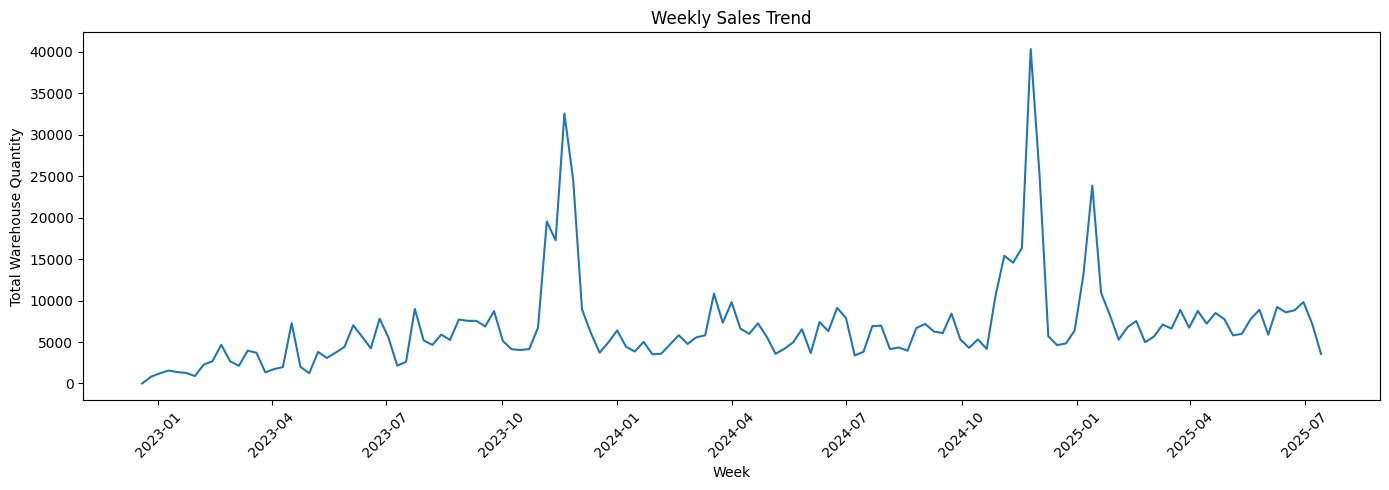

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

weekly_trend = df.groupby('Week')['WareHouseQuantity'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuantity')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Warehouse Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


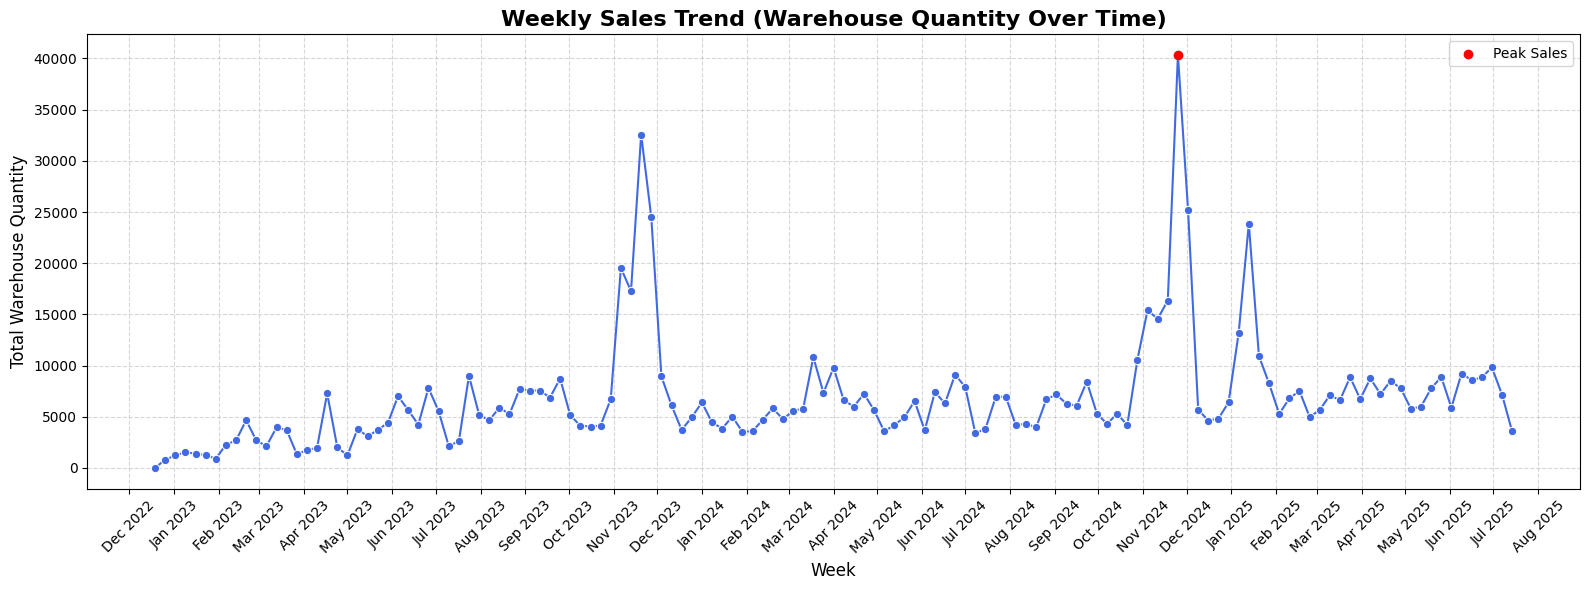

In [17]:
import matplotlib.dates as mdates

# Convert 'Week' to datetime if not already
weekly_trend['Week'] = pd.to_datetime(weekly_trend['Week'])

# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuanity', marker='o', color='royalblue')

# Title and labels
plt.title("Weekly Sales Trend (Warehouse Quantity Over Time)", fontsize=16, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("Total Warehouse Quantity", fontsize=12)

# Format X-axis to show only one label per month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Optional: show every 2nd month to reduce clutter
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight peak
peak = weekly_trend[weekly_trend['WareHouseQuanity'] == weekly_trend['WareHouseQuanity'].max()]
plt.scatter(peak['Week'], peak['WareHouseQuanity'], color='red', label='Peak Sales', zorder=5)
plt.legend()

plt.tight_layout()
plt.show()


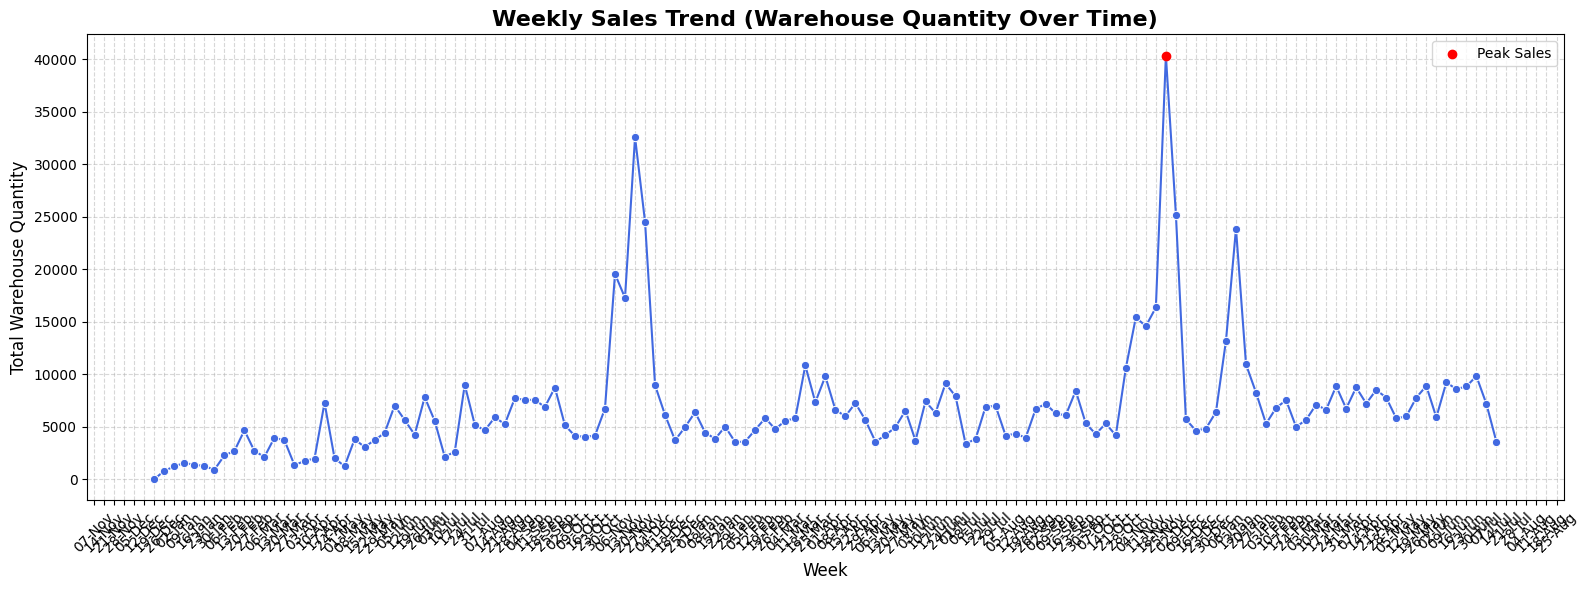

In [18]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Week' to datetime if not already
weekly_trend['Week'] = pd.to_datetime(weekly_trend['Week'])

# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuanity', marker='o', color='royalblue')

# Title and labels
plt.title("Weekly Sales Trend (Warehouse Quantity Over Time)", fontsize=16, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("Total Warehouse Quantity", fontsize=12)

# Use WeekdayLocator for weekly ticks (e.g., every Monday)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

# Rotate x-ticks for readability
plt.xticks(rotation=45)

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight peak week
peak = weekly_trend[weekly_trend['WareHouseQuanity'] == weekly_trend['WareHouseQuanity'].max()]
plt.scatter(peak['Week'], peak['WareHouseQuanity'], color='red', label='Peak Sales', zorder=5)
plt.legend()

plt.tight_layout()
plt.show()


In [19]:
import plotly.express as px

fig = px.line(
    weekly_trend,
    x='Week',
    y='WareHouseQuanity',
    title="Weekly Sales Trend (Warehouse Quantity Over Time)",
)

fig.update_traces(mode='lines+markers', line_color='deepskyblue', marker=dict(size=6))

fig.update_layout(
    width=1600,
    height=600,
    xaxis_title="Week",
    yaxis_title="Total Warehouse Quantity",
    hovermode="x unified",
    template='plotly_dark',  # 🔧 Dark theme here
    
    # X-axis setup for weekly clarity
    xaxis=dict(
        tickformat="%d-%b",
        tickangle=45,
        tickmode='linear',
        tick0=weekly_trend['Week'].min(),
        dtick=604800000,  # One week in ms
        rangeslider=dict(visible=True)
    )
)

fig.show()


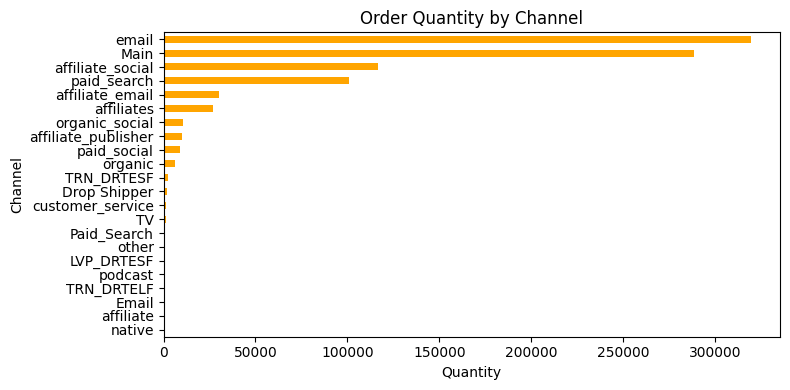

In [20]:
channel_orders = df.groupby('Channel')['WareHouseQuanity'].sum().sort_values()

plt.figure(figsize=(8, 4))
channel_orders.plot(kind='barh', color='orange')
plt.title("Order Quantity by Channel")
plt.xlabel("Quantity")
plt.tight_layout()
plt.show()


In [21]:
df['Channel'].value_counts()

Channel
email                  253631
Main                   230477
affiliate_social       104434
paid_search             83601
affiliate_email         26846
affiliates              23662
organic_social           9005
affiliate_publisher      8730
paid_social              7908
organic                  5172
TRN_DRTESF               2418
Drop Shipper             1438
TV                       1069
customer_service          926
Paid_Search               411
other                     317
LVP_DRTESF                221
TRN_DRTELF                134
Email                     126
affiliate                  94
podcast                    55
native                     28
Name: count, dtype: int64

### Ignored the case that is email and Email 

In [22]:
# Convert all values in 'Channel' to lowercase
df['Channel'] = df['Channel'].str.lower()

# Optional: strip leading/trailing whitespaces if needed
df['Channel'] = df['Channel'].str.strip()

# Get updated value counts
channel_counts = df['Channel'].value_counts()
print(channel_counts)


Channel
email                  253757
main                   230477
affiliate_social       104434
paid_search             84012
affiliate_email         26846
affiliates              23662
organic_social           9005
affiliate_publisher      8730
paid_social              7908
organic                  5172
trn_drtesf               2418
drop shipper             1438
tv                       1069
customer_service          926
other                     317
lvp_drtesf                221
trn_drtelf                134
affiliate                  94
podcast                    55
native                     28
Name: count, dtype: int64


### Combine all affiliates into affiliate

In [23]:
# Normalize case
df['Channel'] = df['Channel'].str.lower().str.strip()

# Replace all affiliate-related variants with 'affiliate'
df['Channel'] = df['Channel'].replace(r'^affiliate.*', 'affiliate', regex=True)

# Get the updated value counts
channel_counts = df['Channel'].value_counts()
print(channel_counts)


Channel
email               253757
main                230477
affiliate           163766
paid_search          84012
organic_social        9005
paid_social           7908
organic               5172
trn_drtesf            2418
drop shipper          1438
tv                    1069
customer_service       926
other                  317
lvp_drtesf             221
trn_drtelf             134
podcast                 55
native                  28
Name: count, dtype: int64


In [24]:
df['Channel'].value_counts()

Channel
email               253757
main                230477
affiliate           163766
paid_search          84012
organic_social        9005
paid_social           7908
organic               5172
trn_drtesf            2418
drop shipper          1438
tv                    1069
customer_service       926
other                  317
lvp_drtesf             221
trn_drtelf             134
podcast                 55
native                  28
Name: count, dtype: int64

In [25]:
# Convert to lowercase and strip spaces
df['Channel'] = df['Channel'].str.lower().str.strip()

# Map all telemarketing-related terms to 'telemarketing'
df['Channel'] = df['Channel'].replace({
    'lvp_drtesf': 'telemarketing',
    'trn_drtelf': 'telemarketing',
    'trn_drtesf': 'telemarketing'
})


In [26]:
print(df['Channel'].value_counts())


Channel
email               253757
main                230477
affiliate           163766
paid_search          84012
organic_social        9005
paid_social           7908
organic               5172
telemarketing         2773
drop shipper          1438
tv                    1069
customer_service       926
other                  317
podcast                 55
native                  28
Name: count, dtype: int64


### Prophet Model Building

c:\forecasting\datasets\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

23:14:23 - cmdstanpy - INFO - Chain [1] start processing
23:14:25 - cmdstanpy - INFO - Chain [1] done processing


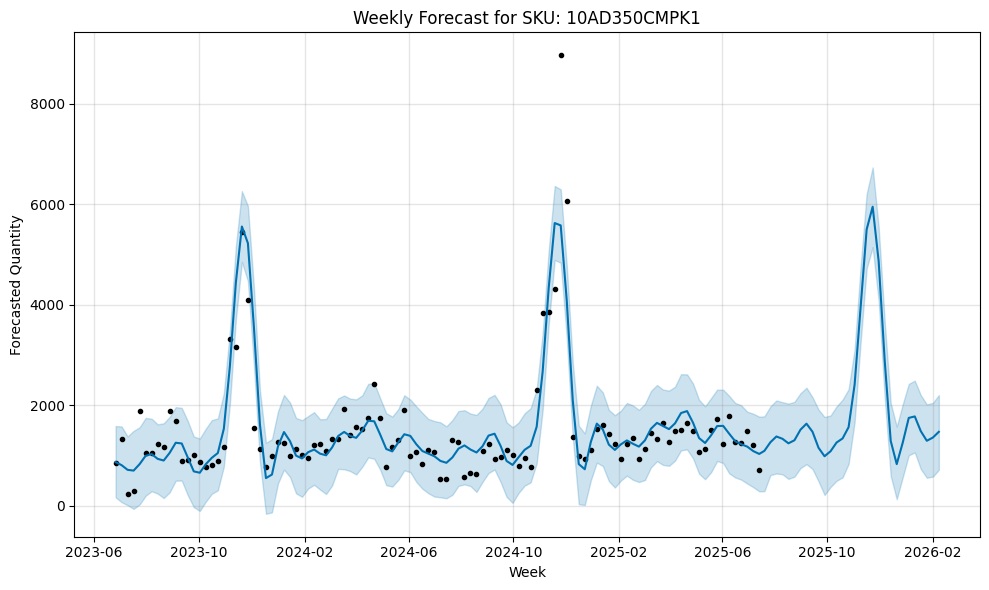

            ds         yhat   yhat_lower   yhat_upper
126 2025-11-23  5953.882316  5147.047870  6737.278527
127 2025-11-30  4863.385738  4079.780223  5546.530793
128 2025-12-07  2892.228452  2158.211222  3672.499267
129 2025-12-14  1290.203719   591.701743  2042.042715
130 2025-12-21   828.862397   129.654769  1576.036413
131 2025-12-28  1256.679689   567.675047  2019.169683
132 2026-01-04  1748.985681  1004.410655  2426.607604
133 2026-01-11  1778.372078  1060.951611  2490.428834
134 2026-01-18  1485.143702   730.495302  2202.385675
135 2026-01-25  1293.643337   556.979211  2018.834586
136 2026-02-01  1356.619029   579.833409  2046.217421
137 2026-02-08  1471.630746   714.256608  2204.333892


In [27]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# STEP 1: Convert OrderDate to weekly
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# STEP 2: Group by Week and SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuanity'].sum().reset_index()

# STEP 3: Filter for SKU = '10AD350CMPK1'
sku = '10AD350CMPK1'
df_sku = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuanity']].copy()
df_sku.columns = ['ds', 'y']

# Skip if there are too few data points
if len(df_sku) < 10:
    print(f"Not enough data for SKU: {sku} ({len(df_sku)} weeks)")
else:
    # Fit Prophet model
    model = Prophet()
    model.fit(df_sku)

    # Forecast 30 weeks ahead
    future = model.make_future_dataframe(periods=30, freq='W')
    forecast = model.predict(future)

    # Plot the forecast
    model.plot(forecast)
    plt.title(f"Weekly Forecast for SKU: {sku}")
    plt.xlabel("Week")
    plt.ylabel("Forecasted Quantity")
    plt.tight_layout()
    plt.show()

    # Optional: View forecast
    result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    print(result.tail(12))


In [28]:
weekly_by_sku

,Week,SKU,WareHouseQuanity
0,2022-12-19,10AD300GRF01,1.0
1,2022-12-19,10AD500GRF02,1.0
2,2022-12-26,10AD01TF01,32.0
3,2022-12-26,10AD02CMPK1,100.0
4,2022-12-26,10AD200CMPK1,13.0
...,...,...,...
6773,2025-07-14,90AD350SC01,37.0
6774,2025-07-14,90AD400AD01-B,6.0
6775,2025-07-14,90AD400AD01-W,29.0
6776,2025-07-14,90AD550AD01,67.0


### Evaluation Metrics

23:15:35 - cmdstanpy - INFO - Chain [1] start processing


METHOD 1: TRAIN-TEST SPLIT VALIDATION
Training data points: 86
Testing data points: 22


23:15:35 - cmdstanpy - INFO - Chain [1] done processing



Accuracy Metrics:
MAE (Mean Absolute Error): 329.34
MSE (Mean Squared Error): 155317.94
RMSE (Root Mean Squared Error): 394.10
MAPE (Mean Absolute Percentage Error): 26.41%
R² Score: -1.39


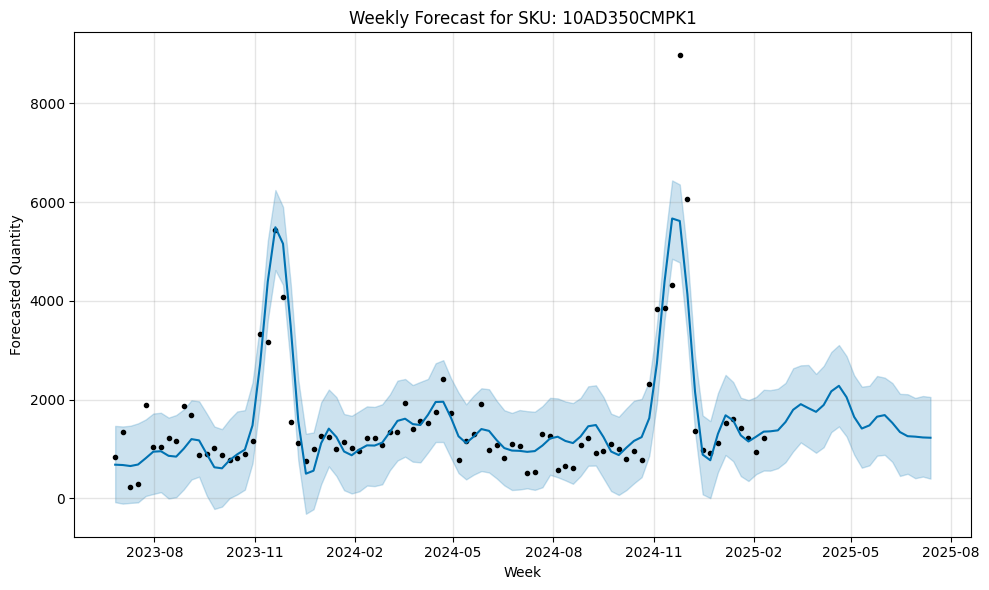

In [31]:
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Your existing code for data preparation
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuanity'].sum().reset_index()

sku = '10AD350CMPK1'
df_sku = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuanity']].copy()
df_sku.columns = ['ds', 'y']

if len(df_sku) < 10:
    print(f"Not enough data for SKU: {sku} ({len(df_sku)} weeks)")
else:
    # METHOD 1: TRAIN-TEST SPLIT VALIDATION
    print("=" * 50)
    print("METHOD 1: TRAIN-TEST SPLIT VALIDATION")
    print("=" * 50)
    
    # Split data: use 80% for training, 20% for testing
    train_size = int(len(df_sku) * 0.8)
    train_data = df_sku[:train_size]
    test_data = df_sku[train_size:]
    
    print(f"Training data points: {len(train_data)}")
    print(f"Testing data points: {len(test_data)}")
    
    # Train model on training data
    model_train = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.01)
    # model_train = Prophet(weekly_seasonality=True, yearly_seasonality=True)

    model_train.fit(train_data)
    
    # Predict on test period
    future_test = model_train.make_future_dataframe(periods=len(test_data), freq='W')
    forecast_test = model_train.predict(future_test)
    
    # Get predictions for test period only
    test_predictions = forecast_test.tail(len(test_data))
    
    # Calculate accuracy metrics
    actual = test_data['y'].values
    predicted = test_predictions['yhat'].values
    
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    r2 = r2_score(actual, predicted)

    print(f"\nAccuracy Metrics:")
    print(f"MAE (Mean Absolute Error): {mae:.2f}")
    print(f"MSE (Mean Squared Error): {mse:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    print(f"R² Score: {r2:.2f}")

    # Plot the forecast
    model_train.plot(forecast_test)
    plt.title(f"Weekly Forecast for SKU: {sku}")
    plt.xlabel("Week")
    plt.ylabel("Forecasted Quantity")
    plt.tight_layout()
    plt.show()

### Actual Vs Predicted Visualization Plots

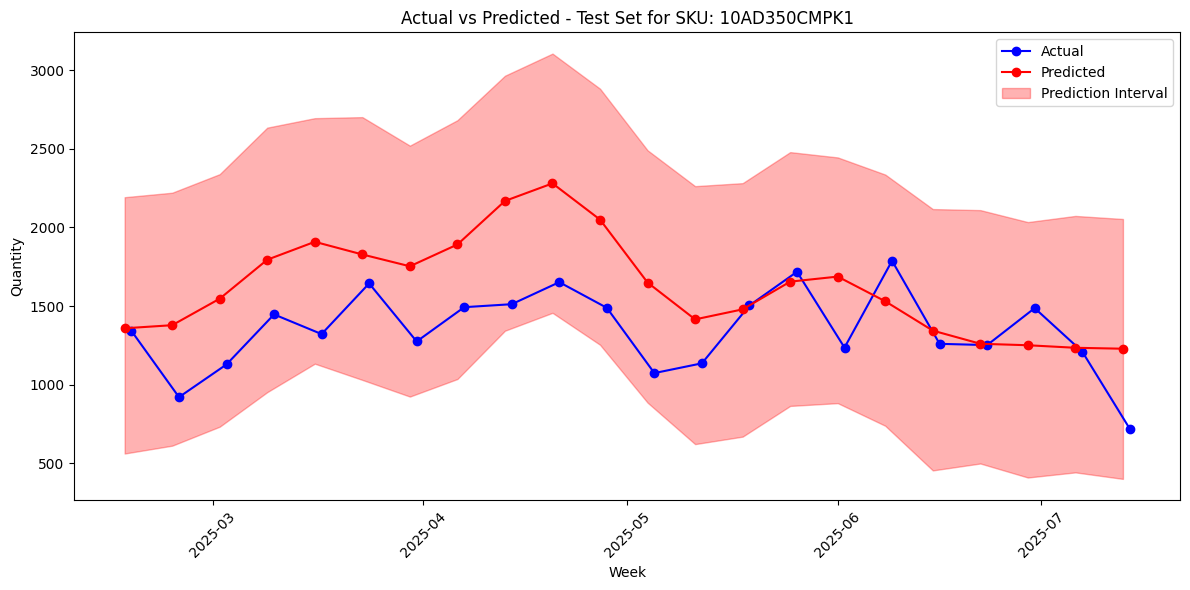

In [32]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(test_data['ds'], actual, 'o-', label='Actual', color='blue')
plt.plot(test_predictions['ds'], predicted, 'o-', label='Predicted', color='red')
plt.fill_between(test_predictions['ds'], 
                     test_predictions['yhat_lower'], 
                     test_predictions['yhat_upper'], 
                     alpha=0.3, color='red', label='Prediction Interval')
plt.title(f'Actual vs Predicted - Test Set for SKU: {sku}')
plt.xlabel('Week')
plt.ylabel('Quantity')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Data Splitting: Training and Testing (For Checking Accuracy)
- For Testing : 8 weeks -> May, June 
- Rest of the data for Training -> Excluding July 2025

In [33]:
import pandas as pd

# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create 'Week' column as week start date (Monday)
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# Group weekly by SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuanity'].sum().reset_index()

# Filter for the specific SKU
sku = '10AD350CMPK1'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuanity']].copy()

# Add week start and end dates
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# Filter Test Data: Only May and June 2025
# Filter Test Data: Only weeks strictly within May and June 2025
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-05-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-06-30'))  # Exclude 2025-06-30 week
]


# Filter Train Data: Before May 2025 (strictly excludes May, June, July)
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2025-05-01')
]

# Final output
print("Train Data:")
print(train_data[['Week_Start', 'Week_End', 'WareHouseQuanity']].tail())

print("\nTest Data:")
print(test_data[['Week_Start', 'Week_End', 'WareHouseQuanity']].head())


Train Data:
     Week_Start   Week_End  WareHouseQuanity
5786 2025-03-31 2025-04-06            1275.0
5848 2025-04-07 2025-04-13            1493.0
5909 2025-04-14 2025-04-20            1512.0
5971 2025-04-21 2025-04-27            1652.0
6033 2025-04-28 2025-05-04            1489.0

Test Data:
     Week_Start   Week_End  WareHouseQuanity
6094 2025-05-05 2025-05-11            1074.0
6152 2025-05-12 2025-05-18            1136.0
6216 2025-05-19 2025-05-25            1504.0
6282 2025-05-26 2025-06-01            1718.0
6352 2025-06-02 2025-06-08            1236.0


In [34]:
# Save training and testing data to CSV
train_data[['Week_Start', 'Week_End', 'WareHouseQuanity']].to_csv('training_data.csv', index=False)
test_data[['Week_Start', 'Week_End', 'WareHouseQuanity']].to_csv('testing_data.csv', index=False)

print("Files saved successfully.")


Files saved successfully.


In [35]:
train_data

,Week,WareHouseQuanity,Week_Start,Week_End
875,2023-06-26,846.0,2023-06-26,2023-07-02
934,2023-07-03,1337.0,2023-07-03,2023-07-09
989,2023-07-10,226.0,2023-07-10,2023-07-16
1039,2023-07-17,292.0,2023-07-17,2023-07-23
1094,2023-07-24,1894.0,2023-07-24,2023-07-30
...,...,...,...,...
5786,2025-03-31,1275.0,2025-03-31,2025-04-06
5848,2025-04-07,1493.0,2025-04-07,2025-04-13
5909,2025-04-14,1512.0,2025-04-14,2025-04-20
5971,2025-04-21,1652.0,2025-04-21,2025-04-27


#### Forecast for Single SKU for above Training data


23:17:10 - cmdstanpy - INFO - Chain [1] start processing
23:17:10 - cmdstanpy - INFO - Chain [1] done processing


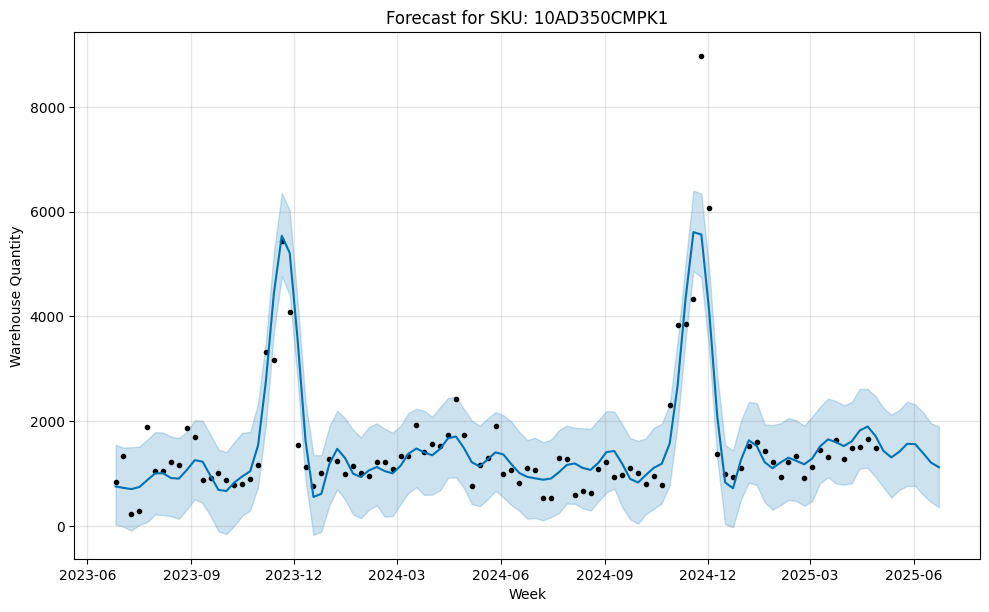


Forecast vs Actuals (May & June 2025):
            ds         yhat  WareHouseQuanity
97  2025-05-05  1432.169989            1074.0
98  2025-05-12  1307.715151            1136.0
99  2025-05-19  1413.984658            1504.0
100 2025-05-26  1567.032434            1718.0
101 2025-06-02  1561.043261            1236.0
102 2025-06-09  1391.039974            1788.0
103 2025-06-16  1209.896606            1260.0
104 2025-06-23  1120.706253            1252.0


In [36]:
from prophet import Prophet
import matplotlib.pyplot as plt

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(test_data[['Week_Start', 'WareHouseQuanity']],
                                 left_on='ds', right_on='Week_Start', how='left')

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'yhat', 'WareHouseQuanity']])


23:17:17 - cmdstanpy - INFO - Chain [1] start processing
23:17:17 - cmdstanpy - INFO - Chain [1] done processing


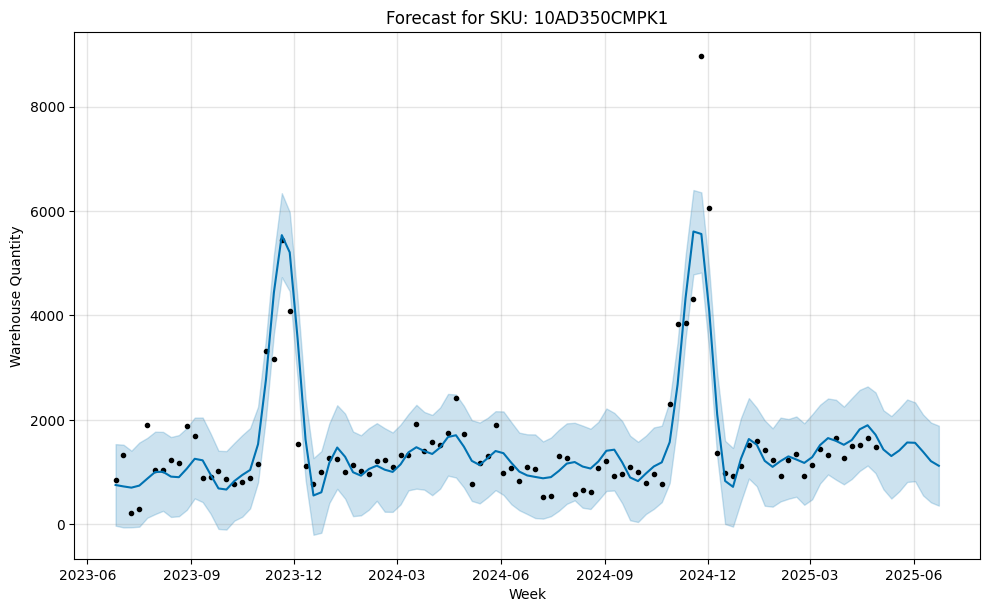


Forecast vs Actuals (May & June 2025):
            ds         yhat  WareHouseQuanity
97  2025-05-05  1432.169989            1074.0
98  2025-05-12  1307.715151            1136.0
99  2025-05-19  1413.984658            1504.0
100 2025-05-26  1567.032434            1718.0
101 2025-06-02  1561.043261            1236.0
102 2025-06-09  1391.039974            1788.0
103 2025-06-16  1209.896606            1260.0
104 2025-06-23  1120.706253            1252.0

Accuracy Metrics:
MAE  (Mean Absolute Error):        209.28
MSE  (Mean Squared Error):         58955.57
RMSE (Root Mean Squared Error):    242.81
MAPE (Mean Absolute % Error):      15.77%
R²   (R-squared Score):            0.06


In [37]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'yhat', 'WareHouseQuanity']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns for clarity
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop rows with missing values
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Extract values
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print all metrics
print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")



In [39]:
# Add Start_Week and End_Week
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)

# Calculate the difference between actual and predicted
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# Rearrange and rename columns
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)



# Save to CSV
final_result.to_csv("actual_vs_forecast.csv", index=False)

# Display final formatted output
print("\nFinal Forecast Results:")
final_result



Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual
97,2025-05-05,2025-05-11,1074.0,1432.169989,358.169989
98,2025-05-12,2025-05-18,1136.0,1307.715151,171.715151
99,2025-05-19,2025-05-25,1504.0,1413.984658,-90.015342
100,2025-05-26,2025-06-01,1718.0,1567.032434,-150.967566
101,2025-06-02,2025-06-08,1236.0,1561.043261,325.043261
102,2025-06-09,2025-06-15,1788.0,1391.039974,-396.960026
103,2025-06-16,2025-06-22,1260.0,1209.896606,-50.103394
104,2025-06-23,2025-06-29,1252.0,1120.706253,-131.293747


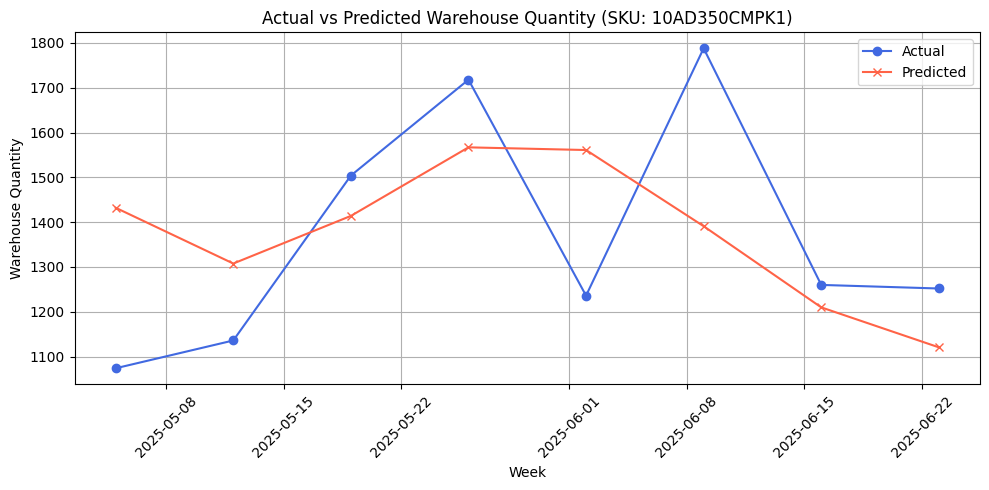

In [40]:
# STEP 8: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Hyperparameter Tuning

23:20:40 - cmdstanpy - INFO - Chain [1] start processing
23:20:40 - cmdstanpy - INFO - Chain [1] done processing


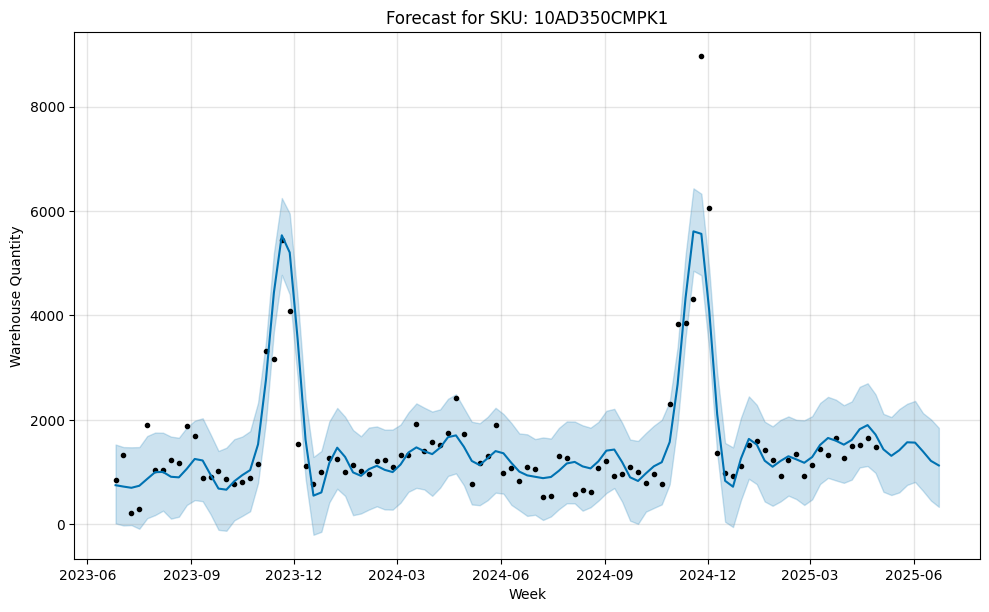


Forecast vs Actuals (May & June 2025):
            ds         yhat  WareHouseQuanity
97  2025-05-05  1435.911975            1074.0
98  2025-05-12  1311.986809            1136.0
99  2025-05-19  1418.413234            1504.0
100 2025-05-26  1571.209969            1718.0
101 2025-06-02  1564.988309            1236.0
102 2025-06-09  1395.330781            1788.0
103 2025-06-16  1215.282126            1260.0
104 2025-06-23  1127.518743            1252.0

Accuracy Metrics:
MAE  (Mean Absolute Error):        207.64
MSE  (Mean Squared Error):         58842.72
RMSE (Root Mean Squared Error):    242.58
MAPE (Mean Absolute % Error):      15.69%
R²   (R-squared Score):            0.06


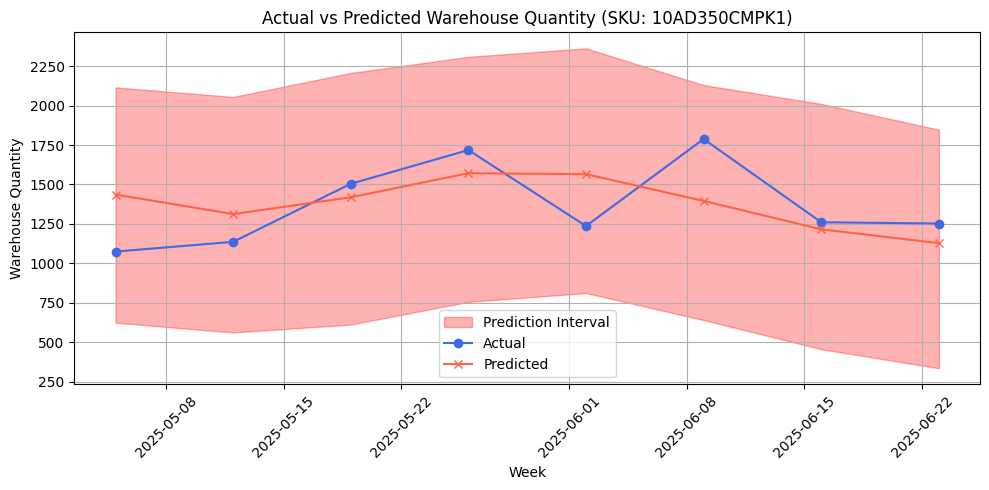

In [42]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
# model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
model = Prophet(yearly_seasonality=True)
model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'yhat', 'WareHouseQuanity']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns for clarity
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop rows with missing values
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Extract values
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print all metrics
print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted + Prediction Interval
plt.figure(figsize=(10, 5))
# Prediction interval (shaded)
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')

# Actual and predicted
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')

# Formatting
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [43]:
# Add Start_Week and End_Week
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)

# Calculate the difference between actual and predicted
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# Rearrange and rename columns
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)



# Save to CSV
final_result.to_csv("actual_vs_forecast.csv", index=False)

# Display final formatted output
print("\nFinal Forecast Results:")
final_result



Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual
97,2025-05-05,2025-05-11,1074.0,1435.911975,361.911975
98,2025-05-12,2025-05-18,1136.0,1311.986809,175.986809
99,2025-05-19,2025-05-25,1504.0,1418.413234,-85.586766
100,2025-05-26,2025-06-01,1718.0,1571.209969,-146.790031
101,2025-06-02,2025-06-08,1236.0,1564.988309,328.988309
102,2025-06-09,2025-06-15,1788.0,1395.330781,-392.669219
103,2025-06-16,2025-06-22,1260.0,1215.282126,-44.717874
104,2025-06-23,2025-06-29,1252.0,1127.518743,-124.481257


#### Parameters:
    - `yearly_seasonality=True,
    - weekly_seasonality=True,
    - seasonality_mode='multiplicative',  # test both additive/multiplicative
    - changepoint_prior_scale=0.1,        # adjust sensitivity
    - seasonality_prior_scale=10.0

23:22:14 - cmdstanpy - INFO - Chain [1] start processing
23:22:14 - cmdstanpy - INFO - Chain [1] done processing


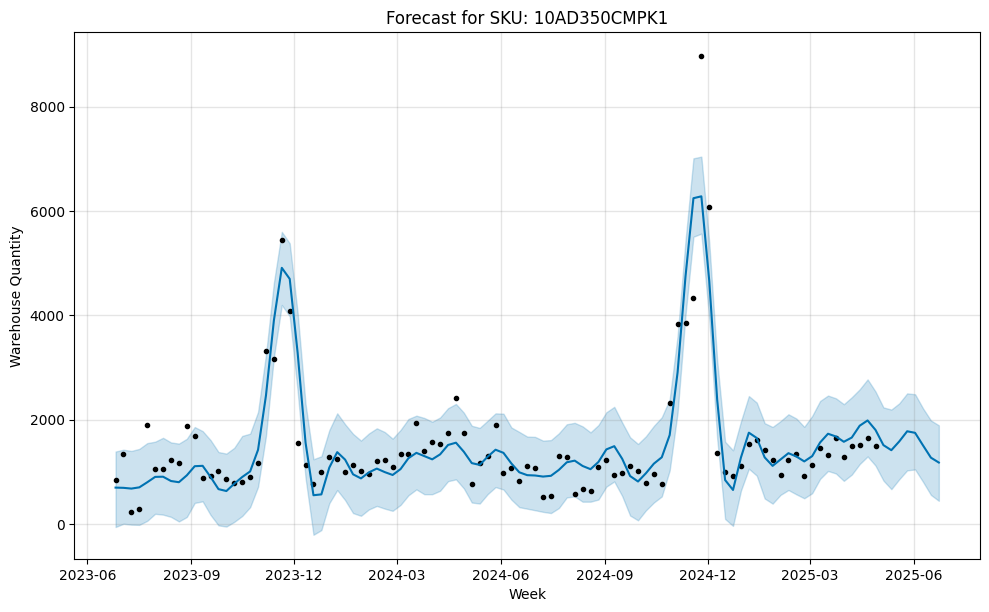


Forecast vs Actuals (May & June 2025):
            ds  WareHouseQuanity         yhat
97  2025-05-05            1074.0  1509.589286
98  2025-05-12            1136.0  1412.671809
99  2025-05-19            1504.0  1580.366386
100 2025-05-26            1718.0  1775.308128
101 2025-06-02            1236.0  1745.545770
102 2025-06-09            1788.0  1504.905951
103 2025-06-16            1260.0  1269.323104
104 2025-06-23            1252.0  1175.885410

Accuracy Metrics:
MAE  (Mean Absolute Error):        215.50
MSE  (Mean Squared Error):         77632.61
RMSE (Root Mean Squared Error):    278.63
MAPE (Mean Absolute % Error):      17.15%
R²   (R-squared Score):            -0.24


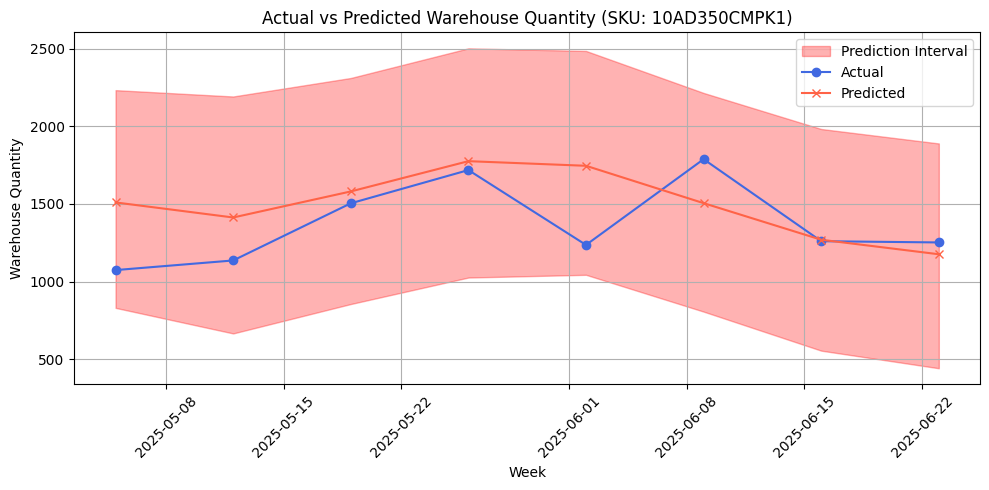

In [44]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
# model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
# model = Prophet(yearly_seasonality=True)
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='multiplicative',  # test both additive/multiplicative
    changepoint_prior_scale=0.1,        # adjust sensitivity
    seasonality_prior_scale=10.0
)
model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuanity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns for clarity
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop rows with missing values
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Extract values
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print all metrics
print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted + Prediction Interval
plt.figure(figsize=(10, 5))
# Prediction interval (shaded)
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')

# Actual and predicted
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')

# Formatting
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





#### Used additive mode

23:22:58 - cmdstanpy - INFO - Chain [1] start processing
23:22:58 - cmdstanpy - INFO - Chain [1] done processing


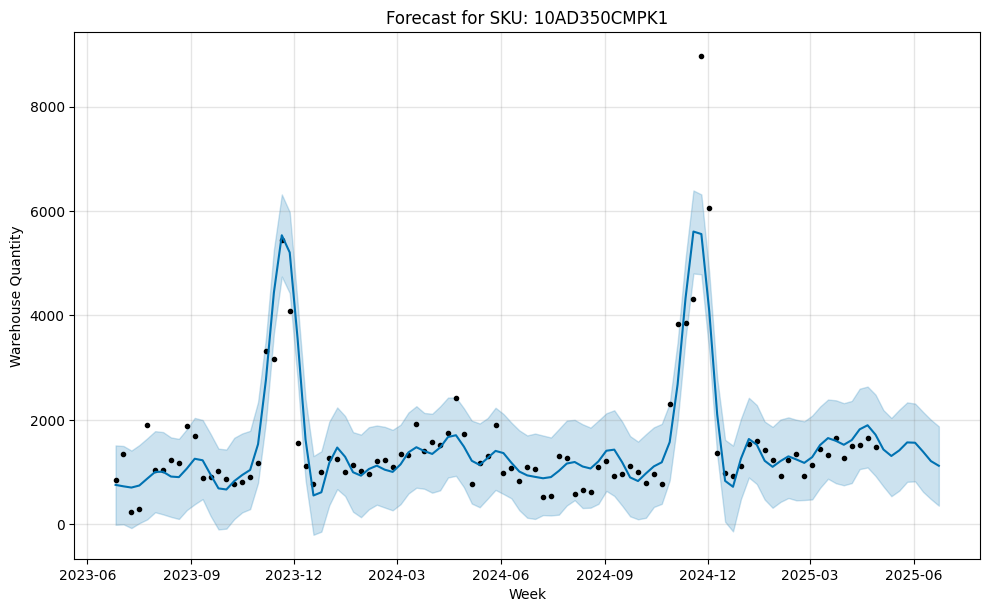


Forecast vs Actuals (May & June 2025):
            ds  WareHouseQuanity         yhat
97  2025-05-05            1074.0  1432.208297
98  2025-05-12            1136.0  1308.136711
99  2025-05-19            1504.0  1414.615689
100 2025-05-26            1718.0  1567.748061
101 2025-06-02            1236.0  1561.742873
102 2025-06-09            1788.0  1391.528216
103 2025-06-16            1260.0  1209.894496
104 2025-06-23            1252.0  1120.047997

Accuracy Metrics:
MAE  (Mean Absolute Error):        209.28
MSE  (Mean Squared Error):         58966.20
RMSE (Root Mean Squared Error):    242.83
MAPE (Mean Absolute % Error):      15.78%
R²   (R-squared Score):            0.06


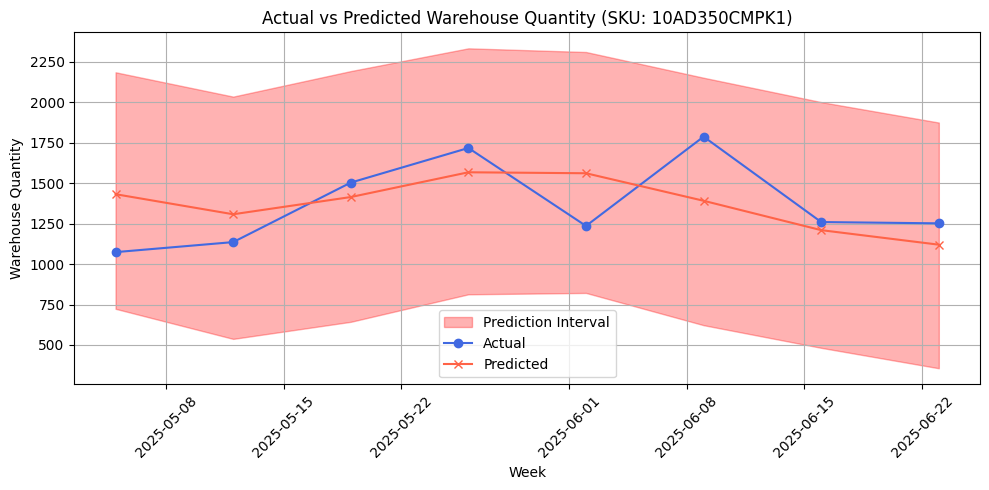

In [45]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
# model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
# model = Prophet(yearly_seasonality=True)
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',  # test both additive/multiplicative
    changepoint_prior_scale=0.1,        # adjust sensitivity
    seasonality_prior_scale=10.0
)
model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuanity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns for clarity
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop rows with missing values
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Extract values
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print all metrics
print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted + Prediction Interval
plt.figure(figsize=(10, 5))
# Prediction interval (shaded)
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')

# Actual and predicted
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')

# Formatting
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





### Changed changepoint_prior_scale=0.5 with seasonality_prior_scale=10.0

23:23:04 - cmdstanpy - INFO - Chain [1] start processing
23:23:05 - cmdstanpy - INFO - Chain [1] done processing


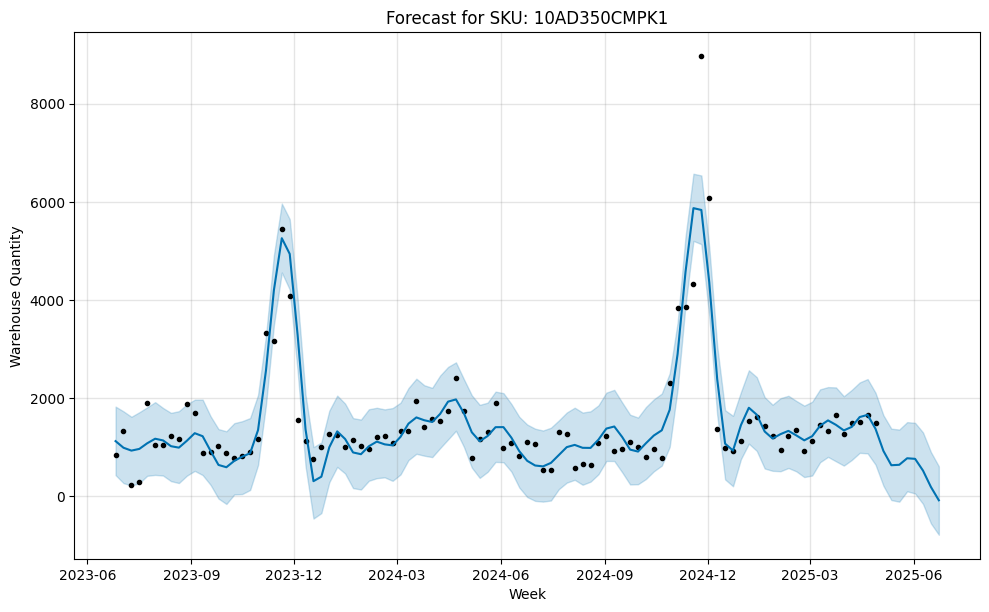


Forecast vs Actuals (May & June 2025):
            ds  WareHouseQuanity        yhat
97  2025-05-05            1074.0  921.023336
98  2025-05-12            1136.0  630.015758
99  2025-05-19            1504.0  638.906870
100 2025-05-26            1718.0  772.106778
101 2025-06-02            1236.0  760.163772
102 2025-06-09            1788.0  520.576239
103 2025-06-16            1260.0  186.716100
104 2025-06-23            1252.0  -84.248915

Accuracy Metrics:
MAE  (Mean Absolute Error):        827.84
MSE  (Mean Squared Error):         836600.58
RMSE (Root Mean Squared Error):    914.66
MAPE (Mean Absolute % Error):      59.08%
R²   (R-squared Score):            -12.38


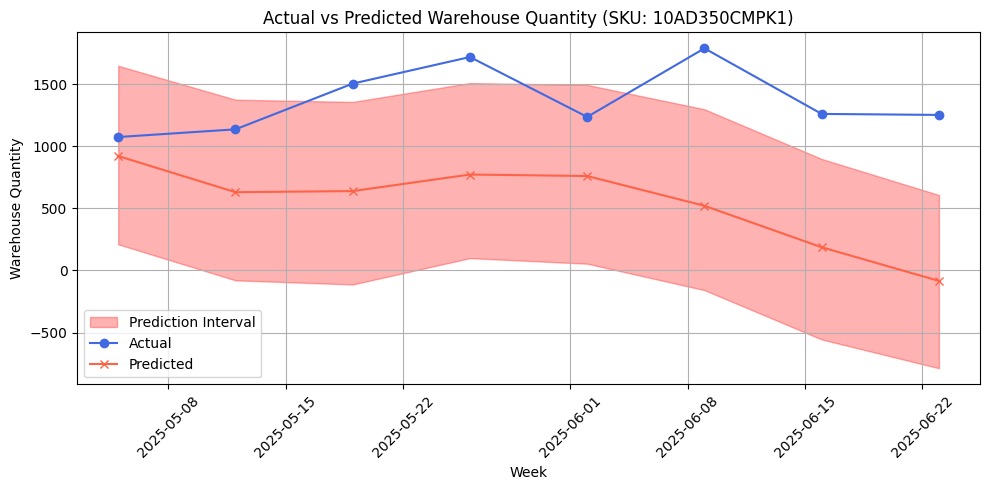

In [46]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
# model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
# model = Prophet(yearly_seasonality=True)
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',  # test both additive/multiplicative
    changepoint_prior_scale=0.5,        # adjust sensitivity
    seasonality_prior_scale=10.0
)
model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuanity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns for clarity
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop rows with missing values
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Extract values
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print all metrics
print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted + Prediction Interval
plt.figure(figsize=(10, 5))
# Prediction interval (shaded)
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')

# Actual and predicted
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')

# Formatting
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





23:24:48 - cmdstanpy - INFO - Chain [1] start processing
23:24:48 - cmdstanpy - INFO - Chain [1] done processing


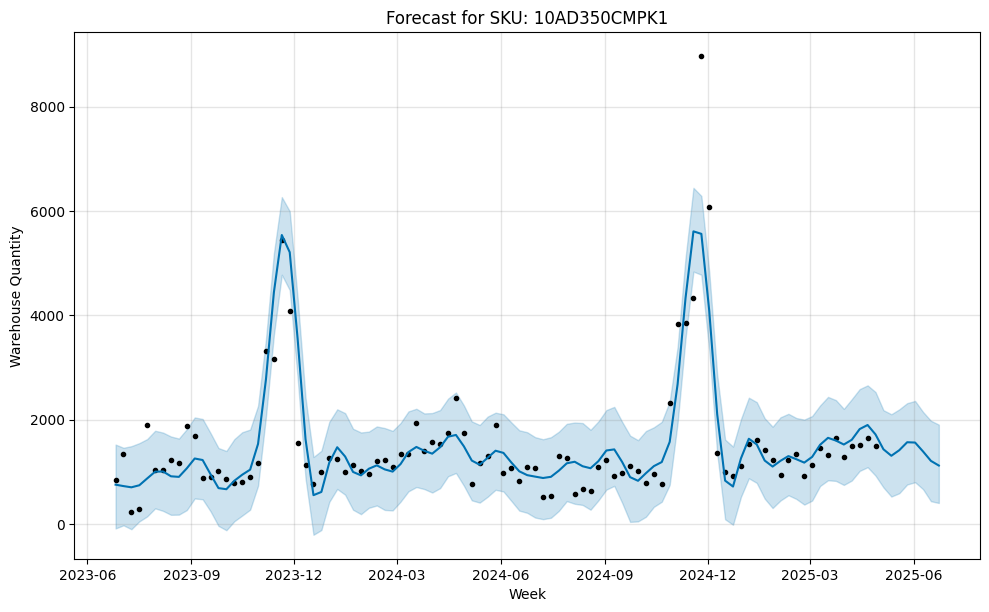


Forecast vs Actuals (May & June 2025):
            ds  WareHouseQuanity         yhat
97  2025-05-05            1074.0  1431.740655
98  2025-05-12            1136.0  1307.186793
99  2025-05-19            1504.0  1413.409980
100 2025-05-26            1718.0  1566.468562
101 2025-06-02            1236.0  1560.493364
102 2025-06-09            1788.0  1390.439977
103 2025-06-16            1260.0  1209.164526
104 2025-06-23            1252.0  1119.809914

Accuracy Metrics:
MAE  (Mean Absolute Error):        209.52
MSE  (Mean Squared Error):         58982.50
RMSE (Root Mean Squared Error):    242.86
MAPE (Mean Absolute % Error):      15.79%
R²   (R-squared Score):            0.06


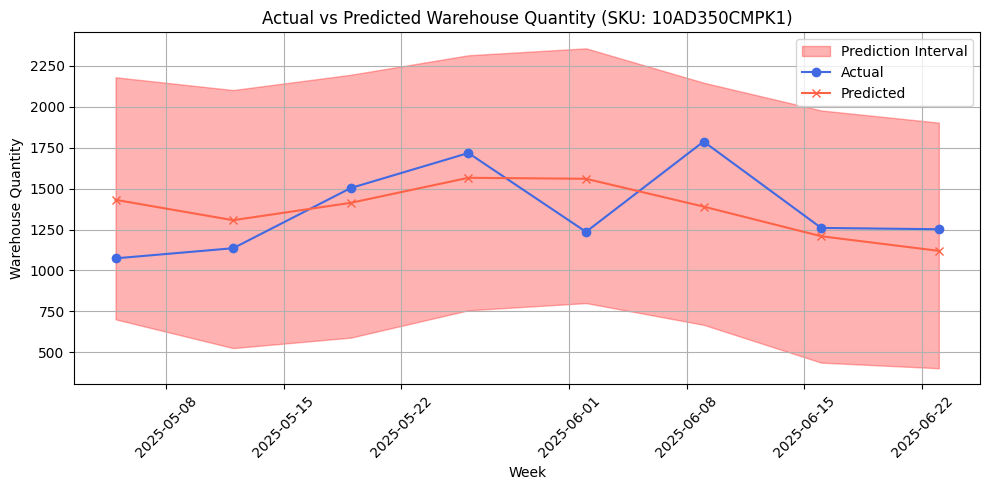


Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual
97,2025-05-05,2025-05-11,1074.0,1431.740655,357.740655
98,2025-05-12,2025-05-18,1136.0,1307.186793,171.186793
99,2025-05-19,2025-05-25,1504.0,1413.409980,-90.590020
100,2025-05-26,2025-06-01,1718.0,1566.468562,-151.531438
101,2025-06-02,2025-06-08,1236.0,1560.493364,324.493364
102,2025-06-09,2025-06-15,1788.0,1390.439977,-397.560023
103,2025-06-16,2025-06-22,1260.0,1209.164526,-50.835474
104,2025-06-23,2025-06-29,1252.0,1119.809914,-132.190086


In [48]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
# model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
# model = Prophet(yearly_seasonality=True)
model = Prophet(
    yearly_seasonality=True,
    # weekly_seasonality=True,
    seasonality_mode='additive',  # test both additive/multiplicative
    changepoint_prior_scale=0.1,        # adjust sensitivity check 0.1,0.01, 0.001, 0.5, 0.05, 0.0001, 0.10
    seasonality_prior_scale=10
)
model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuanity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns for clarity
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop rows with missing values
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Extract values
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print all metrics
print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted + Prediction Interval
plt.figure(figsize=(10, 5))
# Prediction interval (shaded)
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')

# Actual and predicted
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')

# Formatting
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# STEP 9: Create final results DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# Rearranging and renaming columns
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)

# Display final formatted output
print("\nFinal Forecast Results:")
final_result

# Optional: Save to CSV
# final_result.to_csv("actual_vs_forecast_results.csv", index=False)


### Added Holidays Parameter

23:25:42 - cmdstanpy - INFO - Chain [1] start processing
23:25:42 - cmdstanpy - INFO - Chain [1] done processing


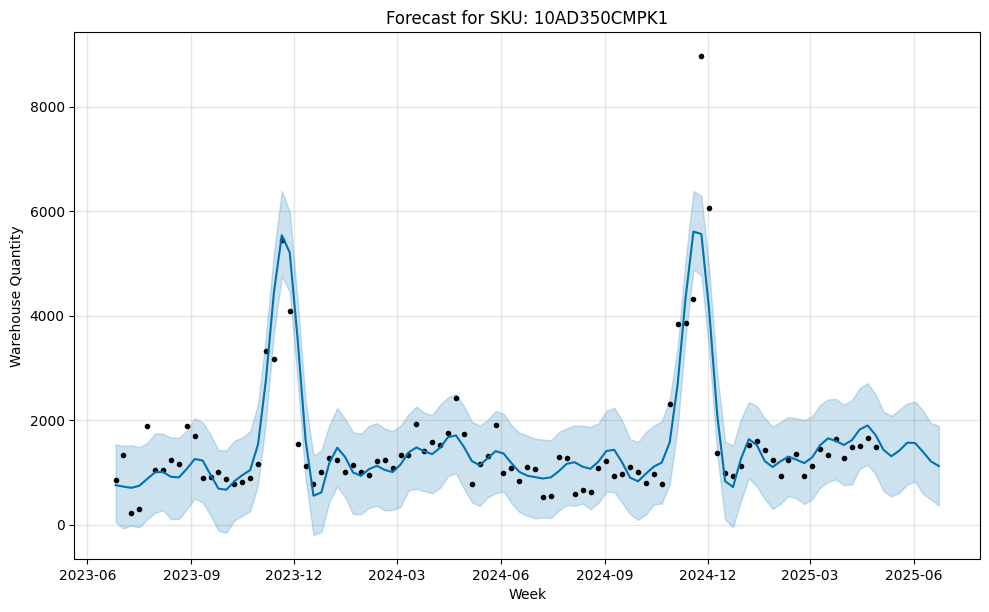


Forecast vs Actuals (May & June 2025):
            ds  WareHouseQuanity         yhat
97  2025-05-05            1074.0  1431.755532
98  2025-05-12            1136.0  1307.189788
99  2025-05-19            1504.0  1413.392883
100 2025-05-26            1718.0  1566.549533
101 2025-06-02            1236.0  1560.469087
102 2025-06-09            1788.0  1390.436159
103 2025-06-16            1260.0  1209.179870
104 2025-06-23            1252.0  1119.830939

Accuracy Metrics:
MAE  (Mean Absolute Error):        209.50
MSE  (Mean Squared Error):         58978.80
RMSE (Root Mean Squared Error):    242.86
MAPE (Mean Absolute % Error):      15.79%
R²   (R-squared Score):            0.06


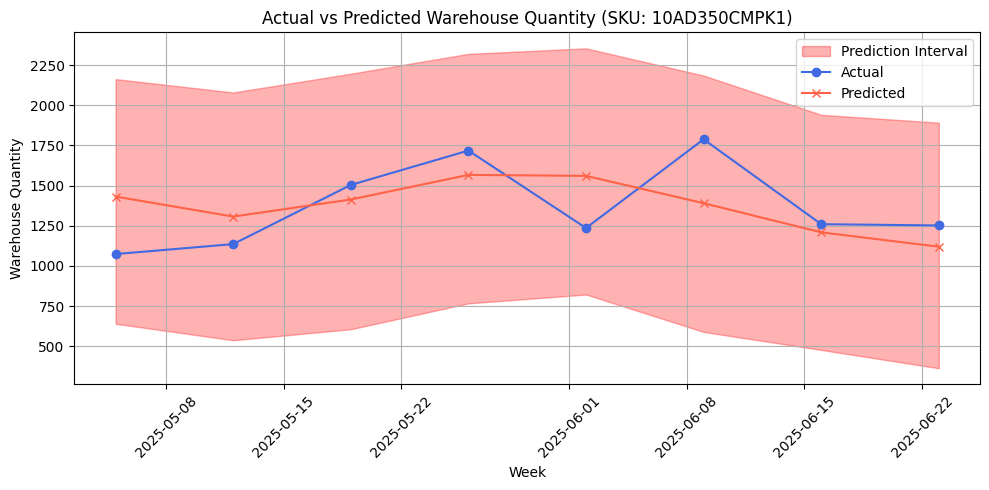


Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual
97,2025-05-05,2025-05-11,1074.0,1431.755532,357.755532
98,2025-05-12,2025-05-18,1136.0,1307.189788,171.189788
99,2025-05-19,2025-05-25,1504.0,1413.392883,-90.607117
100,2025-05-26,2025-06-01,1718.0,1566.549533,-151.450467
101,2025-06-02,2025-06-08,1236.0,1560.469087,324.469087
102,2025-06-09,2025-06-15,1788.0,1390.436159,-397.563841
103,2025-06-16,2025-06-22,1260.0,1209.179870,-50.820130
104,2025-06-23,2025-06-29,1252.0,1119.830939,-132.169061


In [50]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
# model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
# model = Prophet(yearly_seasonality=True)
# model = Prophet(
#     yearly_seasonality=True,
#     # weekly_seasonality=True,
#     seasonality_mode='additive',  # test both additive/multiplicative
#     changepoint_prior_scale=0.1,        # adjust sensitivity checked 0.1,0.01, 0.001, 0.5, 0.05, 0.0001, 0.10
#     seasonality_prior_scale=10
# )

model = Prophet(
    yearly_seasonality=True,
    # weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=0.001  # Strength of holiday effect
)
model.add_country_holidays(country_name='US')  # Add US holidays

model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuanity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns for clarity
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop rows with missing values
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Extract values
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print all metrics
print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted + Prediction Interval
plt.figure(figsize=(10, 5))
# Prediction interval (shaded)
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')

# Actual and predicted
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')

# Formatting
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# STEP 9: Create final results DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# Rearranging and renaming columns
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)

# Display final formatted output
print("\nFinal Forecast Results:")
final_result

# Optional: Save to CSV
# final_result.to_csv("actual_vs_forecast_results.csv", index=False)


### Final Results

23:25:48 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2023-06-26 to 2025-04-28
 - Total Years:  3
 - Total Months: 23
 - Total Weeks:  97

Testing Data Range:  2025-05-05 to 2025-06-23
 - Total Years:  1
 - Total Months: 2
 - Total Weeks:  8


23:25:48 - cmdstanpy - INFO - Chain [1] done processing


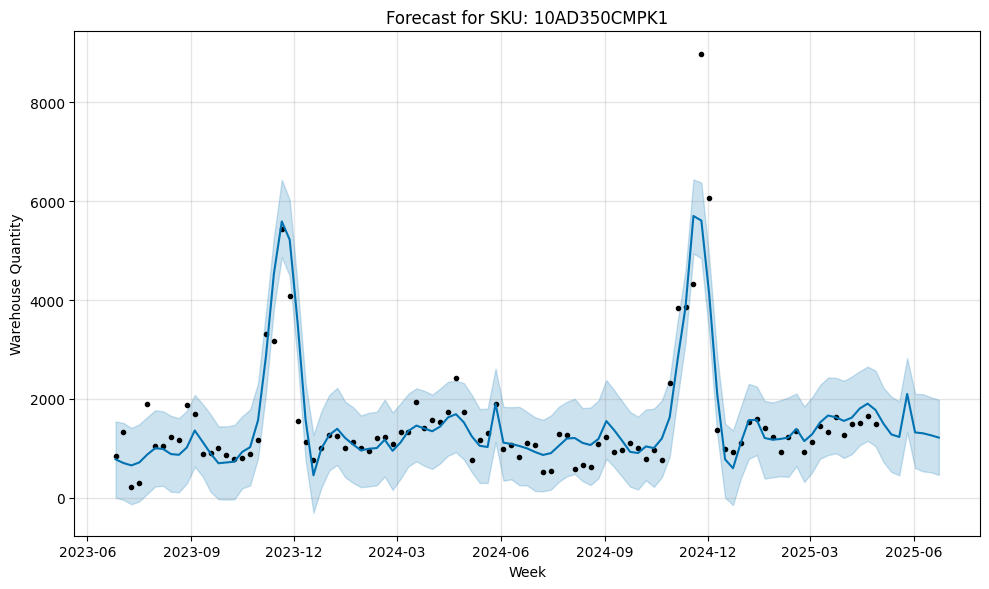

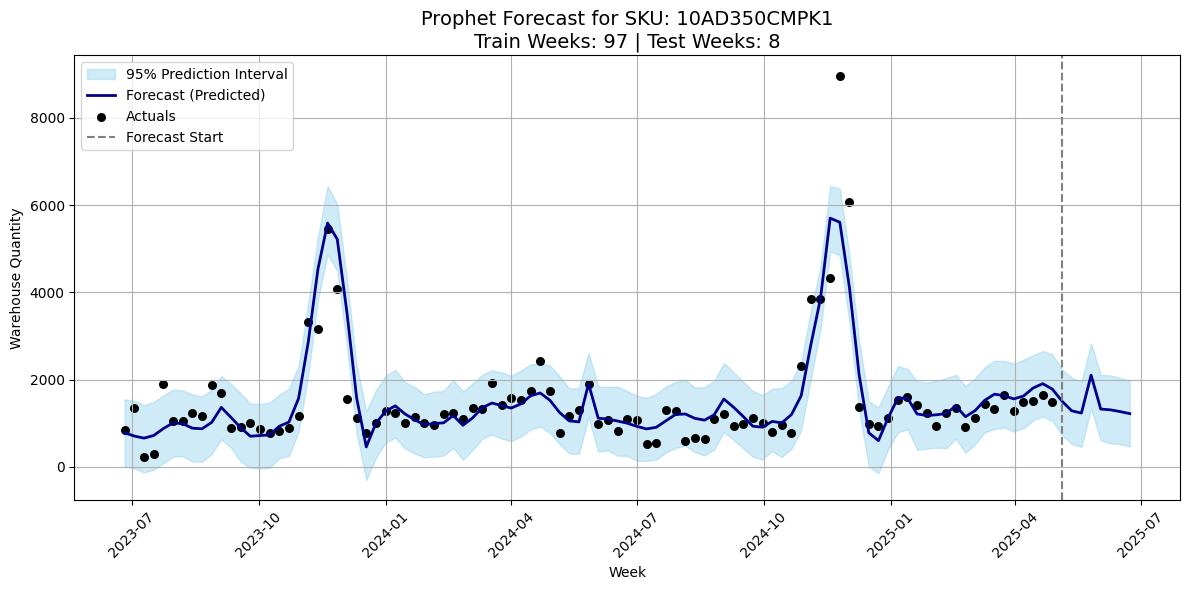


Forecast vs Actuals (May & June 2025):
            ds  WareHouseQuanity         yhat
97  2025-05-05            1074.0  1501.409706
98  2025-05-12            1136.0  1281.907469
99  2025-05-19            1504.0  1230.859142
100 2025-05-26            1718.0  2100.206950
101 2025-06-02            1236.0  1322.474304
102 2025-06-09            1788.0  1304.968466
103 2025-06-16            1260.0  1264.634729
104 2025-06-23            1252.0  1217.612646

Accuracy Metrics:
MAE  (Mean Absolute Error):        229.65
MSE  (Mean Squared Error):         83332.17
RMSE (Root Mean Squared Error):    288.67
MAPE (Mean Absolute % Error):      16.27%
R²   (R-squared Score):            -0.33


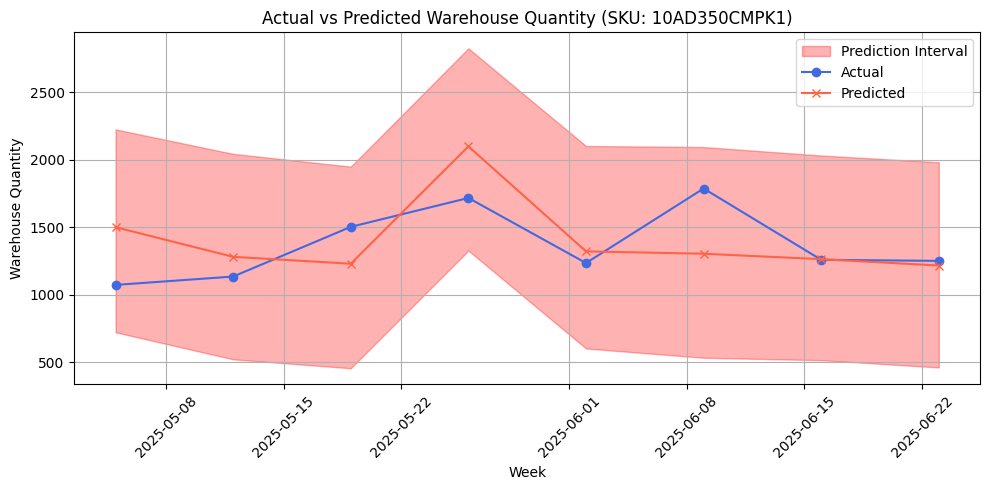


Final Forecast Results with Percent Difference:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual,Percent_Difference
97,2025-05-05,2025-05-11,1074.0,1501.409706,427.409706,39.8%
98,2025-05-12,2025-05-18,1136.0,1281.907469,145.907469,12.84%
99,2025-05-19,2025-05-25,1504.0,1230.859142,-273.140858,-18.16%
100,2025-05-26,2025-06-01,1718.0,2100.206950,382.206950,22.25%
101,2025-06-02,2025-06-08,1236.0,1322.474304,86.474304,7.0%
102,2025-06-09,2025-06-15,1788.0,1304.968466,-483.031534,-27.02%
103,2025-06-16,2025-06-22,1260.0,1264.634729,4.634729,0.37%
104,2025-06-23,2025-06-29,1252.0,1217.612646,-34.387354,-2.75%


In [51]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    growth='linear',
    yearly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.010,
    seasonality_prior_scale=20,
    holidays_prior_scale=20
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval(Using Prophet default)
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Updated): Enhanced Forecast Plot

# Extract historical actuals
historical = prophet_df.copy()
historical['label'] = 'Actuals'

# Prepare forecast line
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

# Plot setup
plt.figure(figsize=(12, 6))

# Confidence interval
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')

# Forecast line
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)

# Actuals as scatter points
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

# Vertical line for training-test boundary
test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

# Title with time span info
plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuanity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop missing
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Metrics
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted with interval
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Create final result DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# New: Add Percent Difference column
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Create final result
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)

# Round and add percent sign
final_result['Percent_Difference'] = final_result['Percent_Difference'].round(2).astype(str) + '%'



# Optional: Save to CSV
final_result.to_csv("actual_vs_predicted_forecast_results.csv", index=False)

# Print final result
print("\nFinal Forecast Results with Percent Difference:")
final_result


In [52]:
# pip install git+https://github.com/ARM-software/mango.git

  Cloning https://github.com/ARM-software/mango.git to c:\users\nilam wadhavane\appdata\local\temp\pip-req-build-gjln5c8m
  Resolved https://github.com/ARM-software/mango.git to commit 273552995170757ebe158e3d85a8b0e06912262a
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for arm-mango: filename=arm_mango-1.5.1-py3-none-any.whl size=33612 sha256=2c5cc44d3669e7996af6cfe1e03d0958a0c24f3b8f14e715dea228efeaa429e2
  Stored in directory: C:\Users\Nilam Wadhavane\AppData\Local\Temp\pip-ephem-wheel-cache-cl91hu5f\wheels\bc\b9\42\e4924621a296b3a789809e81ab5c44c29b96d6ad5d165c3f7a
Successfully built arm-mango
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/ARM-software/mango.git 'C:\Users\Nilam Wadhavane\AppData\Local\Temp\pip-req-build-gjln5c8m'


In [53]:
# pip install optuna


Note: you may need to restart the kernel to use updated packages.


### Find out Best Params With Mango
`Mango refers to a Python library called Mango that is used for efficient hyperparameter optimization. It is particularly useful when tuning machine learning or time series models like Prophet.`
    
- `changepoint_prior_scale`
 Definition: Controls the flexibility of the trend. A smaller value makes the trend less flexible (smoother), while a larger value allows the model to adapt to sudden trend changes.
Typical Range: 0.001 to 0.5
- `seasonality_prior_scale`
Definition: Controls the flexibility of the seasonality component. Larger values allow the model to fit larger seasonal fluctuations.
Typical Range: 0.01 to 50
- `holidays_prior_scale`
Definition: Controls the strength of the holiday effect. Larger values allow larger holiday effects.
Typical Range: 0.01 to 10

Note: This only has effect if holidays are defined in the model.
- seasonality_mode
Definition: Determines how seasonality is added to the model.

    a: `additive`: Seasonality is added linearly.

    b: `multiplicative`: Seasonality scales with the trend.

When to Use:

Use `additive` when seasonality is `constant` over time.

Use `multiplicative` when seasonality `increases/decreases` with the trend.

In [54]:
import pandas as pd
from prophet import Prophet
import optuna
from sklearn.metrics import mean_absolute_error

# ----------------------------
# Prepare data
# ----------------------------
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuanity'].sum().reset_index()

# Filter specific SKU
sku = '10AD350CMPK1'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuanity']].copy()
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# Split train/test
train_data = df_sku_weekly[df_sku_weekly['Week_Start'] < pd.to_datetime('2025-05-01')]
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-05-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-06-30'))
]

# Prophet format
train_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'})
test_df = test_data[['Week_Start', 'WareHouseQuanity']].rename(columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'})

# ----------------------------
# Define objective function
# ----------------------------
def objective(trial):
    params = {
        'changepoint_prior_scale': trial.suggest_categorical('changepoint_prior_scale', [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]),
        'seasonality_prior_scale': trial.suggest_categorical('seasonality_prior_scale', [1.0, 5.0, 10.0, 15.0, 20.0,40.0, 50.0]),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
        'growth': 'linear',
        'weekly_seasonality': trial.suggest_categorical('weekly_seasonality', [True, False]),
        'yearly_seasonality': trial.suggest_categorical('yearly_seasonality', [True, False]),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.001, 0.1, log=True),
        'daily_seasonality': False,
    }

    model = Prophet(**params)

    # Optional: Add US holidays
    model.add_country_holidays(country_name='US')

    model.fit(train_df)

    future = model.make_future_dataframe(periods=len(test_df), freq='W-MON')
    forecast = model.predict(future)

    forecast_trim = forecast.set_index('ds').loc[test_df['ds']]

    if forecast_trim.empty or len(forecast_trim) != len(test_df):
        raise ValueError("Forecast does not align with test set")

    mae = mean_absolute_error(test_df['y'].values, forecast_trim['yhat'].values)
    return mae

# ----------------------------
# Run optimization
# ----------------------------
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# ----------------------------
# Best result
# ----------------------------
print("Best Parameters:", study.best_params)
print("Best MAE:", study.best_value)


[I 2025-07-26 23:27:36,939] A new study created in memory with name: no-name-7799d1b1-392c-428a-9018-119a25663f92
23:27:37 - cmdstanpy - INFO - Chain [1] start processing
23:27:37 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-07-26 23:27:37,916] Trial 0 finished with value: 553.9239923421641 and parameters: {'changepoint_prior_scale': 0.0001, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': False, 'holidays_prior_scale': 0.020634698007343084}. Best is trial 0 with value: 553.9239923421641.
23:27:38 - cmdstanpy - INFO - Chain [1] start processing
23:27:45 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-07-26 23:27:45,358] Trial 1 finished with value: 578.9351529626913 and parameters: {'changepoint_prior_scale': 0.0001, 'seasonality_prior_scale': 50.0, 'seasonality_mode': 'additive', 'weekly_seasonality': False, 'yearly_seasonality': False, 'holidays_prior_scale': 0.07598860910960722}. Best is trial 0 with v

Best Parameters: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive', 'weekly_seasonality': False, 'yearly_seasonality': True, 'holidays_prior_scale': 0.007630277916919481}
Best MAE: 198.71941331235604


### Applied Best Parameters on Prophet

23:28:13 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2023-06-26 to 2025-04-28
 - Total Years:  3
 - Total Months: 23
 - Total Weeks:  97

Testing Data Range:  2025-05-05 to 2025-06-23
 - Total Years:  1
 - Total Months: 2
 - Total Weeks:  8


23:28:14 - cmdstanpy - INFO - Chain [1] done processing


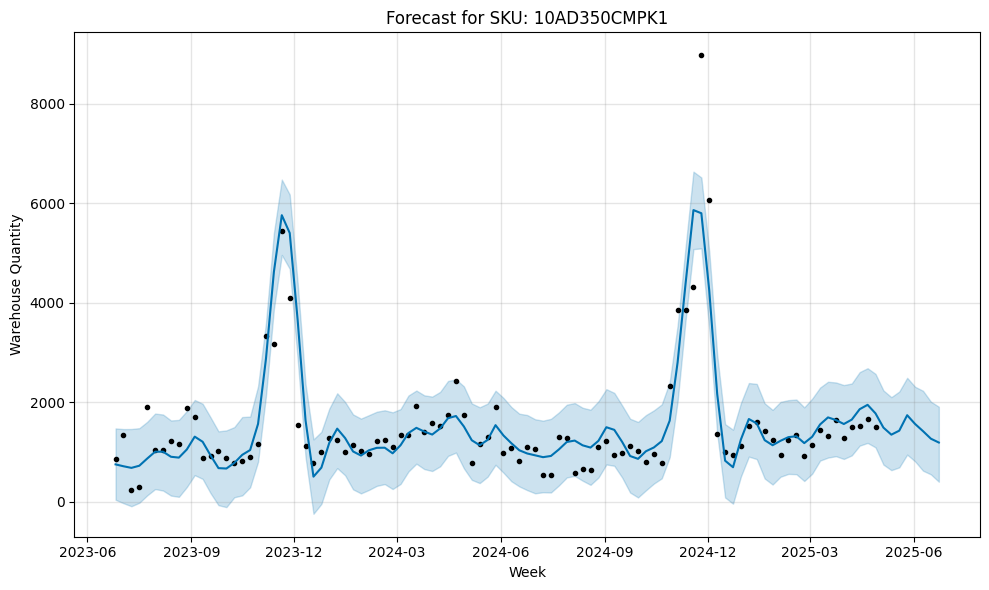

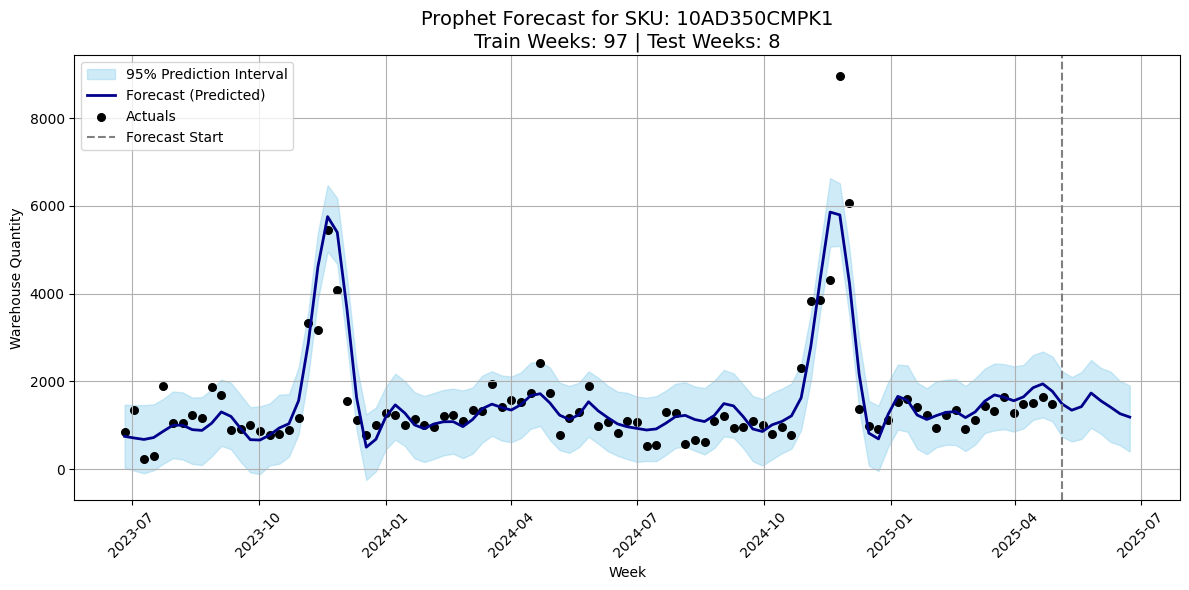


Forecast vs Actuals (May & June 2025):
            ds  WareHouseQuanity         yhat
97  2025-05-05            1074.0  1486.006619
98  2025-05-12            1136.0  1344.303436
99  2025-05-19            1504.0  1424.682563
100 2025-05-26            1718.0  1735.328188
101 2025-06-02            1236.0  1559.229620
102 2025-06-09            1788.0  1415.205617
103 2025-06-16            1260.0  1262.853672
104 2025-06-23            1252.0  1186.275944

Accuracy Metrics:
MAE  (Mean Absolute Error):        185.19
MSE  (Mean Squared Error):         58439.02
RMSE (Root Mean Squared Error):    241.74
MAPE (Mean Absolute % Error):      14.43%
R²   (R-squared Score):            0.07


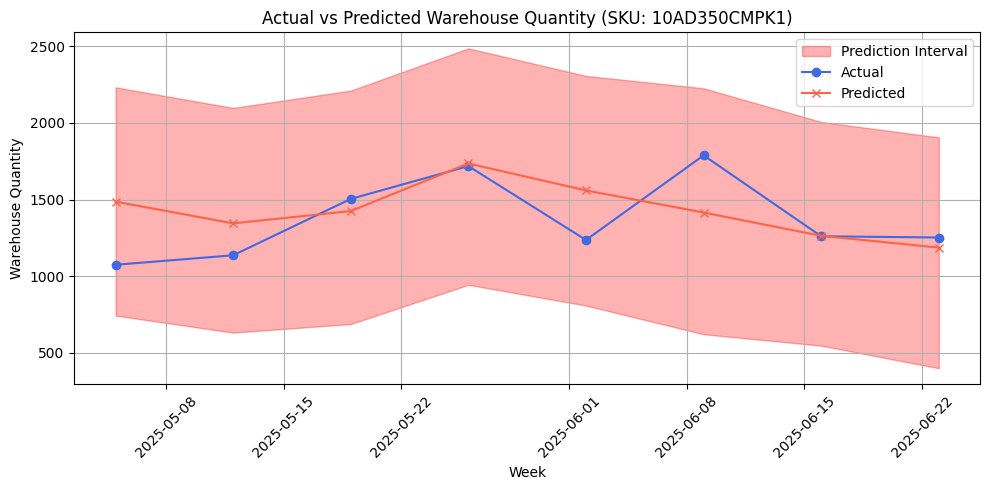


Final Forecast Results with Percent Difference:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual,Percent_Difference
97,2025-05-05,2025-05-11,1074.0,1486.006619,412.006619,38.36%
98,2025-05-12,2025-05-18,1136.0,1344.303436,208.303436,18.34%
99,2025-05-19,2025-05-25,1504.0,1424.682563,-79.317437,-5.27%
100,2025-05-26,2025-06-01,1718.0,1735.328188,17.328188,1.01%
101,2025-06-02,2025-06-08,1236.0,1559.229620,323.229620,26.15%
102,2025-06-09,2025-06-15,1788.0,1415.205617,-372.794383,-20.85%
103,2025-06-16,2025-06-22,1260.0,1262.853672,2.853672,0.23%
104,2025-06-23,2025-06-29,1252.0,1186.275944,-65.724056,-5.25%


In [55]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuanity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuanity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.0001,
    seasonality_prior_scale=20.0,
    holidays_prior_scale=0.04761164916744276
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval(Using Prophet default)
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Updated): Enhanced Forecast Plot

# Extract historical actuals
historical = prophet_df.copy()
historical['label'] = 'Actuals'

# Prepare forecast line
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

# Plot setup
plt.figure(figsize=(12, 6))

# Confidence interval
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')

# Forecast line
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)

# Actuals as scatter points
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

# Vertical line for training-test boundary
test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

# Title with time span info
plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuanity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (May & June 2025):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuanity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns
test_forecast.rename(columns={
    'WareHouseQuanity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop missing
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Metrics
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted with interval
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Create final result DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# New: Add Percent Difference column
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Create final result
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)

# Round and add percent sign
final_result['Percent_Difference'] = final_result['Percent_Difference'].round(2).astype(str) + '%'



# Optional: Save to CSV
final_result.to_csv("actual_vs_predicted_forecast_results.csv", index=False)

# Print final result
print("\nFinal Forecast Results with Percent Difference:")
final_result
